Created by Sanish Bhochhibhoya (03/08/2025)

#### Steps:
1) Boundary Creation
2) Utils Creation
3) Creating a domain2D for each
4) merging domain3d

#### Remaining (to clean):
1) Soil and Util types random generation
2) GWT
3) Mean and Std. of properties
4) Spatial

#### To do:
1) Utils2D
2) SpatialCorrelationMethod2
3) Saving the docs
4) adjustment to different platform like SPECFEM3D, GPRMax

In [1]:
import sys, importlib
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator')

In [2]:
import geomodgen2d.boundary_creator as boundary_defn
from geomodgen2d.domain2d import Domain2D, check_for_remeshing_coordinate_compatibility
import geomodgen2d.general_functions as f
import numpy as np

In [3]:
model_sett={
    'x_limit':5,
    'z_limit':4,
    'del_x_boundary':0.2,    #del_y value for boundary generation and spatial 
    'del_x_spatial':0.5,    #del_y value for boundary generation and spatial 
    'del_z_spatial':0.5,
    'del_x_final': 0.1,  #refining del_z for utilities generation
    'del_z_final': 0.1,
    'refine_interp_method':'linear',
    'random_seed':3,
    'spatial_theta_x':100,
    'spatial_theta_z':0.5,
}


boundary_sett= {'flag_filter':True, 'flag_processing':True,
    'generator_settings_dict':{
                 'generator_option':'uniform',    # options: 'uniform', 'normal', 'fbm'
                 'z_max_change_per_m':4.5,   # Required for 'uniform' only
                 'H':0.75,  # Required for 'fbm' only
                 'method':'daviesharte',   # Required for 'fbm' only
                 'length':15,   # Required for 'fbm' only
                 'std':2     # Required for 'normal' only Mean has to be zero
                },
    'random_init_boundary_option':'random_sort', #options: 'random_sum', 'random_sort', 'equidistant'
    'filter_settings_dict': {
                 'filter_window':20, 
                 'filter_order':3,
                        },
    'boundary_overlap_bottom_priority':True,
    }

n_layers = 3

r_seed = model_sett['random_seed']
rnd_no = np.random.default_rng(seed=r_seed)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0.]]
[[ 0.00000000e+00 -7.45831499e-01 -1.21957259e+00 -6.77278550e-01
  -5.29386885e-01 -1.25995533e+00 -1.38032684e+00 -1.41803450e+00
  -2.03050445e+00 -1.60826558e+00 -2.30365595e+00 -2.49944520e+00
  -2.46931287e+00 -2.59418244e+00 -2.43794501e+00 -2.00983699e+00
  -1.18855593e+00 -1.57699384e+00 -1.30960886e+00 -9.56420071e-01
  -1.32952272e+00 -2.22684057e+00 -1.37461208e+00 -1.73748988e+00
  -2.07231507e+00 -1.36723515e+00]
 [ 0.00000000e+00  1.53293292e-01  1.01650689e-01  5.93549306e-01
  -2.51827880e-01  1.20709292e-01 -1.05651807e-01 -8.42116923e-01
  -5.53216802e-01  2.23418137e-01 -3.03637761e-01 -6.94754009e-02
  -4.32781838e-01  2.38018641e-03  4.02276841e-01 -1.04035395e-01
   4.89760979e-01  7.73534959e-01  1.10257299e+00  1.67870934e+00
   1.55014057e+00  2.01581040e+00  2.69707473e+00  1.98125059e+00
   2.6

<Axes: xlabel='Distance', ylabel='Depth'>

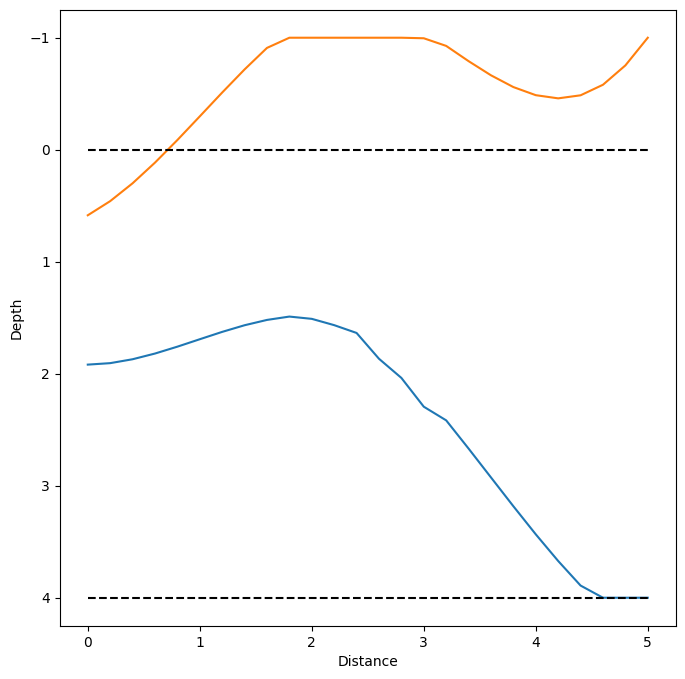

In [4]:
importlib.reload(boundary_defn)
span_x, span_z, del_x_boundary, del_z_spatial = model_sett['x_limit'], model_sett['z_limit'],  model_sett['del_x_boundary'],  model_sett['del_z_spatial']
r_seed, theta_x, theta_z = model_sett['random_seed'], model_sett['spatial_theta_x'], model_sett['spatial_theta_z']
del_x_spatial = model_sett['del_x_spatial']
del_x_final, del_z_final, interp_method = model_sett['del_x_final'], model_sett['del_z_final'], model_sett['refine_interp_method']


boundary = boundary_defn.BoundaryCreator(span_x, span_z, del_x_boundary, del_z_spatial, n_layers)
# print(boundary.boundary_array)
method = 'random_sum'
# method = 'random_sort'
method = 'equidistant'
print(boundary.boundary_array)

# boundary.gen_using_def_process(boundary_sett, rnd_no=rnd_no)
boundary_settings_dict = boundary_sett
boundary.generating_boundary(boundary_settings_dict['generator_settings_dict'], rnd_no = rnd_no)
print(boundary.boundary_array)

boundary.filtering_boundary(**boundary_settings_dict['filter_settings_dict'])
boundary.boundary_init_points(init_boundary=boundary_settings_dict['random_init_boundary_option'] , rnd_no = rnd_no) #None means get one from 
boundary.processing_boundary(boundary_settings_dict['boundary_overlap_bottom_priority'])
print(boundary.boundary_array)

boundary.plot_boundary()


<Axes: xlabel='Distance', ylabel='Depth'>

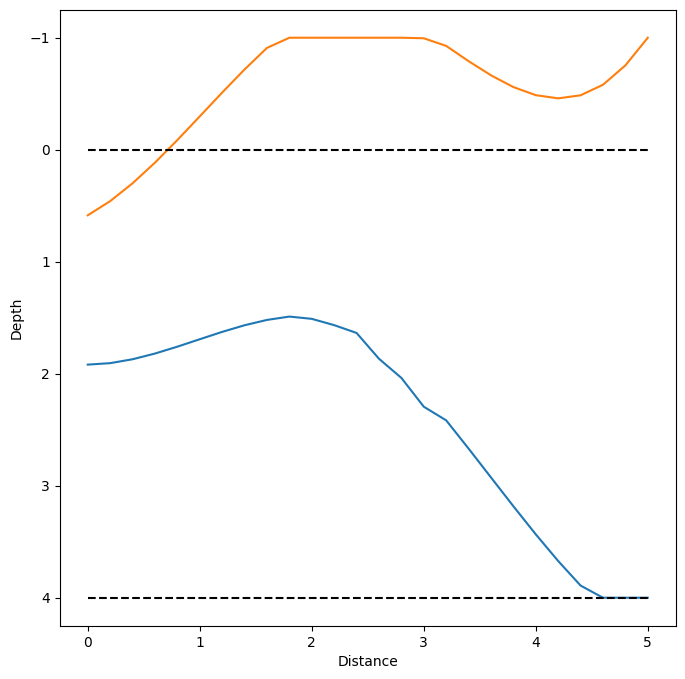

In [5]:
importlib.reload(boundary_defn)
importlib.reload(f)
boundary.remeshing_boundary(model_sett['del_x_final'])
boundary.plot_boundary()


(41, 51)

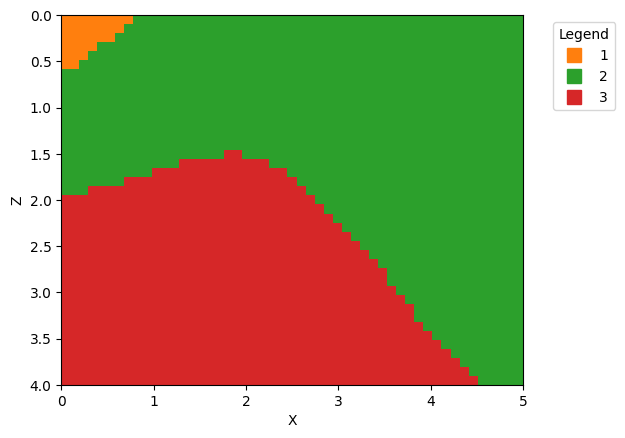

In [6]:
import geomodgen2d.lithological_domain2d as lithological_domain2d
importlib.reload(lithological_domain2d)
name = 'asdf'
lit = lithological_domain2d.LithologicalDomain2D(span_x, span_z, del_x_final, del_z_final, name)
lit.get_matrix_from_boundary(boundary)
# lit.remeshing_layered_matrix(span_x, span_z, del_x_final, del_z_final)
lit.plot2d()

lit.layered_matrix.shape

<Axes: xlabel='X', ylabel='Z'>

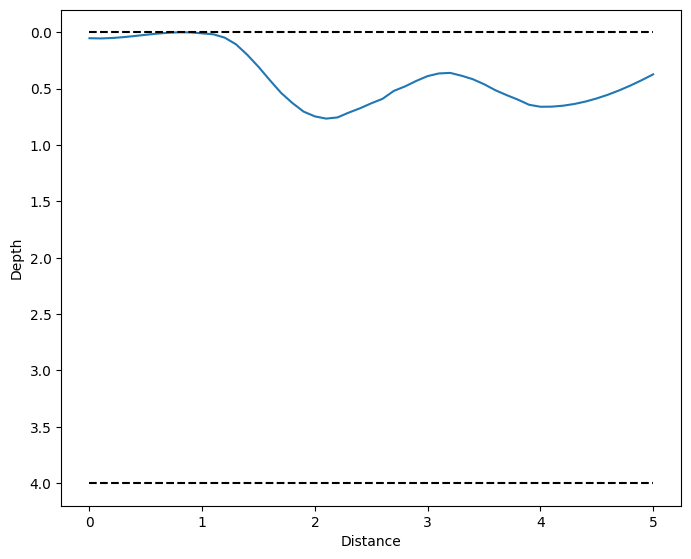

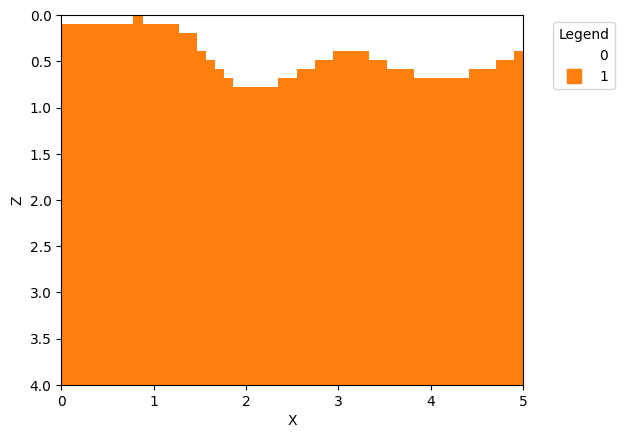

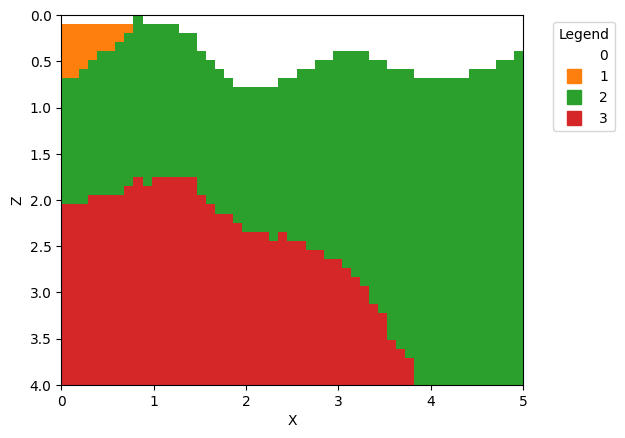

In [7]:
importlib.reload(boundary_defn)
surf = boundary_defn.SurfaceBoundaryCreator(span_x, span_z, del_x_final, del_z_spatial,gen_param=3, rnd_no=rnd_no)
surf.plot_boundary()
lit.add_surface_boundary_to_curr_boundary(surf, method='pile')
lit.plot2d()

In [8]:
surf.boundary_array[0,int(9.0)]

0.001293795649342351

(5, 5)
z_shift_for_surf:
1.0203246952842044 10.0
shift:
[25.  7.]
(9, 9)
z_shift_for_surf:
0.42726797703035135 4.0
shift:
[22. 15.]
(31, 31)
z_shift_for_surf:
0.17992542059329675 1.0
shift:
[39.  7.]
z_shift_for_surf:
0 0.0
shift:
[38.  9.]
(41, 51)


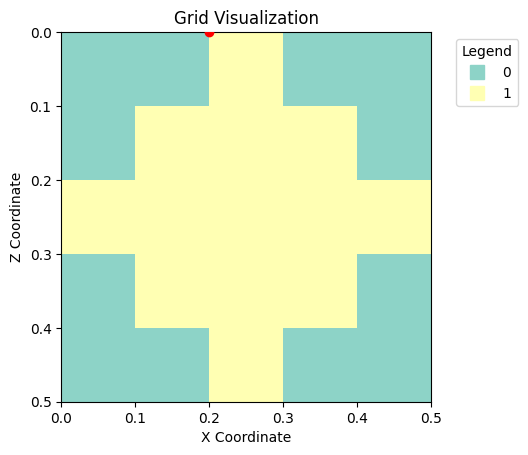

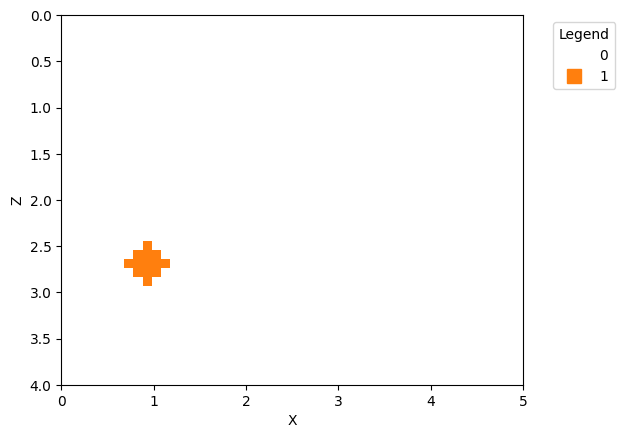

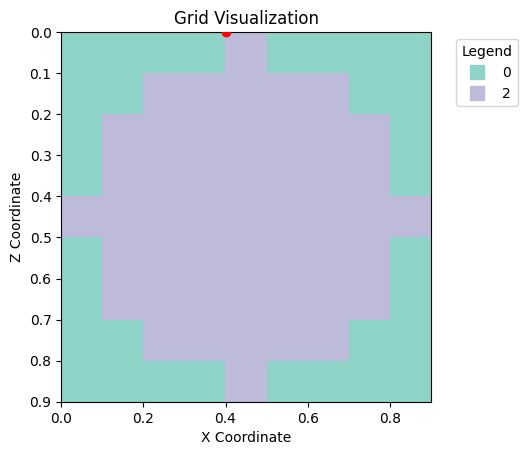

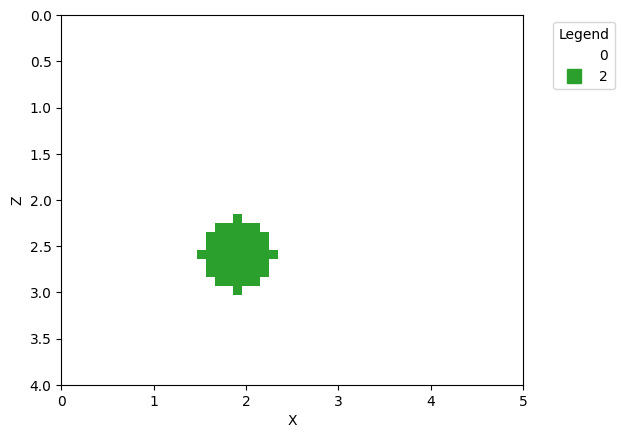

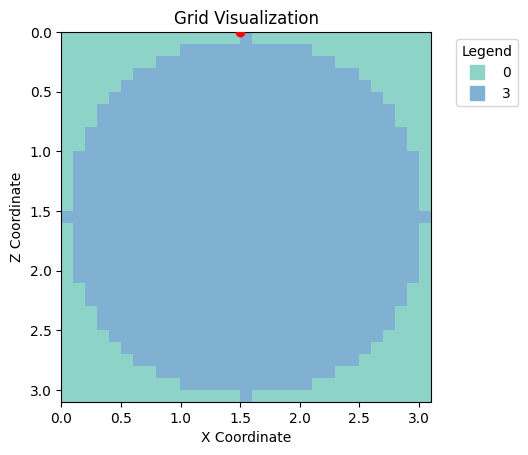

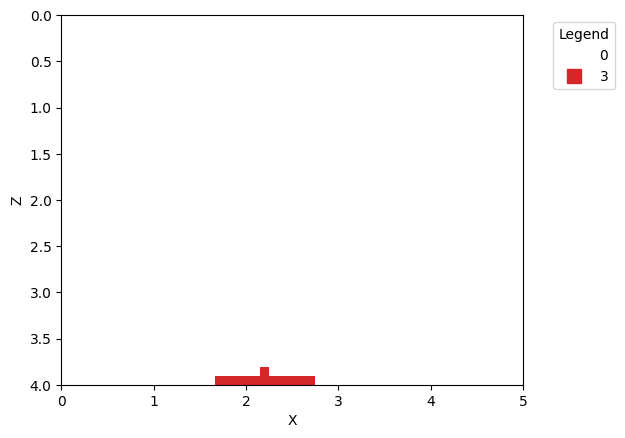

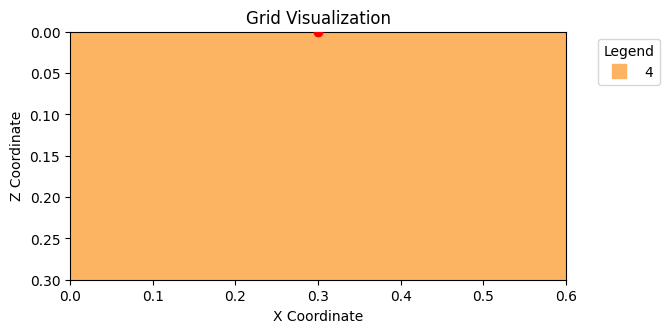

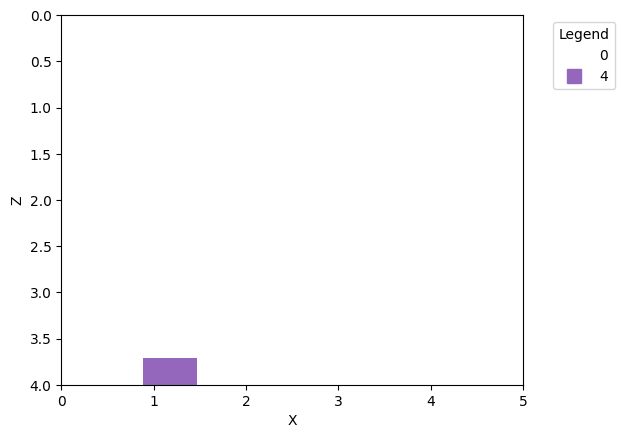

In [33]:
import geomodgen2d.utils_2d as utils_2d
importlib.reload(utils_2d)
importlib.reload(f)
importlib.reload(lithological_domain2d)

r_circ = [.2, .4, 1.5]
d_circ = [1,2,2.3]
circ_shape_layer_utils = {}
i=0
for r, d in zip(r_circ, d_circ):
    x_rnd = rnd_no.uniform(0,lit.span_x,1)[0] # Random x_coord
    circ_shape_class = utils_2d.Utils2D(del_x = model_sett['del_x_final'], del_z = model_sett['del_z_final'])
    circ_shape_class.circular_2d(r, ref='top', util_id = i+1)
    circ_shape_class.plot()
    print(circ_shape_class.grid.shape)
    circ_shape_layer_utils[i] = lithological_domain2d.LithologicalDomain2D_from_Utils2D(span_x, span_z, del_x_final, del_z_final, surfaceBoundaryCreator_class=surf)
    circ_shape_layer_utils[i].get_matrix_from_utils2d(circ_shape_class, [x_rnd,d])
    circ_shape_layer_utils[i].plot2d()
    i+=1

rect_shape_layer = utils_2d.Utils2D(del_x = model_sett['del_x_final'], del_z = model_sett['del_z_final'])
rect_shape_layer.rectangle_2d(lx=.5, lz=.2, util_id=i+1, ref='top')
rect_shape_layer.plot()

d = 1.3
circ_shape_layer_utils[i] = lithological_domain2d.LithologicalDomain2D_from_Utils2D(span_x, span_z, del_x_final, del_z_final)
circ_shape_layer_utils[i].get_matrix_from_utils2d(rect_shape_layer, [x_rnd,d])
circ_shape_layer_utils[i].plot2d()
print(circ_shape_layer_utils[i].layered_matrix.shape)


In [34]:
lit.merge_with_Utils2D_domains([circ_shape_layer_utils[i] for i in range(len(circ_shape_layer_utils))])

<Axes: xlabel='X', ylabel='Z'>

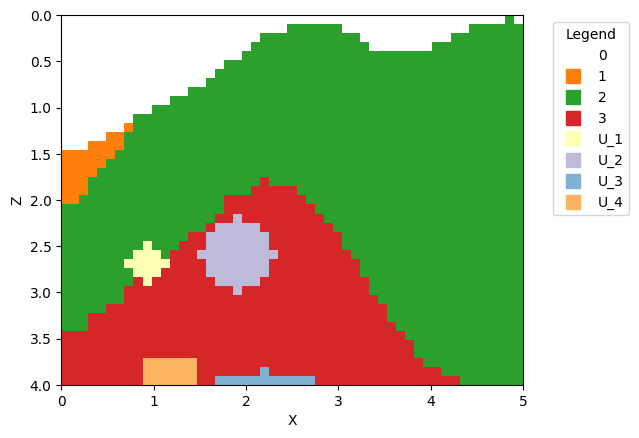

In [35]:
lit.plot2d()